1. In the code below, identify the object and the method.
             df.head()

The object is df and the method is head

2. Is `df.shape` an attribute or a method?

It is an attribute

3. If `df.shape` returns `(75, 8)`, explain what both numbers mean.

It means there are 75 rows and 8 columns in the dataset.

4. What type of pandas object is usually returned by `df["Data_Value"]`?

Series object

5. What type of pandas object is usually returned by `df[["County", "Data_Value"]]`?

Creates a list of column names in the pandas data frame


In [1]:
import pandas as pd

In [2]:
parks = pd.DataFrame({"Park": ["Oak", "Pine", "Maple", "Cedar"], 
                      "Area": [12, 25, 18,40],
                      "Visitors": [120, 250, 180, 310]})

In [3]:
# 6. Write the expression that selects only the `Visitors` column from the `parks` data frame.

parks["Visitors"]

0    120
1    250
2    180
3    310
Name: Visitors, dtype: int64

In [4]:
# 7. Write the expression that selects only `Park` and `Visitors` from the `parks` data frame.
parks[["Park", "Visitors"]]

,Park,Visitors
0,Oak,120
1,Pine,250
2,Maple,180
3,Cedar,310


8. What does `parks.iloc[0]` return?

It returns the first row of parks

Oak, 12, 120


9. What rows are selected by `parks.iloc[1:4]`? 

Rows 2, 3, 4. It is the indexes 1, 2, 3 but not index 4.


In [5]:
parks.iloc[1:4]

,Park,Area,Visitors
1,Pine,25,250
2,Maple,18,180
3,Cedar,40,310


In [6]:
# 10. Write one expression that selects rows 2 through 4 by position and then keeps only `Park` and `Area`.
#parks[1:4][["Park", "Area"]]

#parks[["Park", "Area"]][1:4]
# all three of these codes work
parks.iloc[1:4][["Park", "Area"]]

,Park,Area
1,Pine,25
2,Maple,18
3,Cedar,40


In [7]:
#11. Write a Boolean filter that keeps only parks with `Area > 20`.
large_area = parks[parks["Area"] > 20]

print(large_area)

    Park  Area  Visitors
1   Pine    25       250
3  Cedar    40       310


12. What rows would remain after that filter?

Rows 2 and 4. Indexes 1 and 3

Pine, 25, 250
Cedar, 40, 310


In [8]:
# 13. Create a new DataFrame named `large_parks` containing those rows and make it an independent copy.

large_parks = large_area.copy()

14. Why might `.copy()` be useful after filtering?

Because it creates a separate dataframe that we are able to edit and modify without affecting the original dataset and not get any warnings. 


In [9]:
# 15. Write one line that changes all three column names to `Name`, `Area_ha`, and `Annual_Visitors` using `df.columns = [...]`.
large_parks.columns = ["Name", "Area_ha", "Annual_Visitors"]

print(large_parks)

    Name  Area_ha  Annual_Visitors
1   Pine       25              250
3  Cedar       40              310


16. What problem occurs if the list assigned to `.columns` has only two names while the DataFrame has three columns?

It creates a ValueError because the number of names in the list assigned to .columns must match the number of columns in the data fram

In [10]:
values = pd.Series(["12.5", "18.0", "missing", "22.5"])

print(values.dtypes)

str


17. Why might pandas store these values as strings rather than numbers?

Because the series has "missing" in it, which is not numeric, so pandas can't treat the whole series as a numeric column

In [11]:
# 18. Write code using `pd.to_numeric(..., errors="coerce")` to convert the Series.
values = pd.to_numeric(values, errors="coerce")
print(values.dtypes)

float64


19. What happens to the value `"missing"` when `errors="coerce"` is used?

It is converted to NaN (not a number)

20. What does `.isna().sum()` tell you?

It tells you the total amount of rows that have an Na value, which means it counts the number of missing values in the dataframe

21. Explain the difference between `dropna()` and `fillna()`.

dropna() gets rid of the rows that have na values, while fillna() replaces na with whatever value you want. If you put 0 in fillna() that can be risky because it will change your dataset


In [12]:
# 22. Write code that sorts `parks` from the highest to lowest number of visitors.
highest = parks.sort_values("Visitors", ascending=False)

print(highest)

    Park  Area  Visitors
3  Cedar    40       310
1   Pine    25       250
2  Maple    18       180
0    Oak    12       120


In [13]:
# 23. Write code to calculate the mean and median of `Visitors`.
mean_value = parks["Visitors"].mean()
median_value = parks["Visitors"].median()

print(median_value)
print(mean_value)

215.0
215.0


24. In a strongly right-skewed distribution, which is usually larger: the mean or the median? Why?

In a right-skewed distribution there is a long tail to the right which goes toward higher values. These few, but high values in the right tail increase the average upwards, causing the mean to be greater than the median.

25. In a histogram, what does `bins=10` control?

In controls how many rectangles are on your histogram. It controls the intervals the data is divided into

26. What is `ax` in `ax = df["Value"].plot(kind="hist")`?

It is the object that allows you to customize your graph with adding things like a title and axis titles

Text(0, 0.5, 'Number of Visitors')

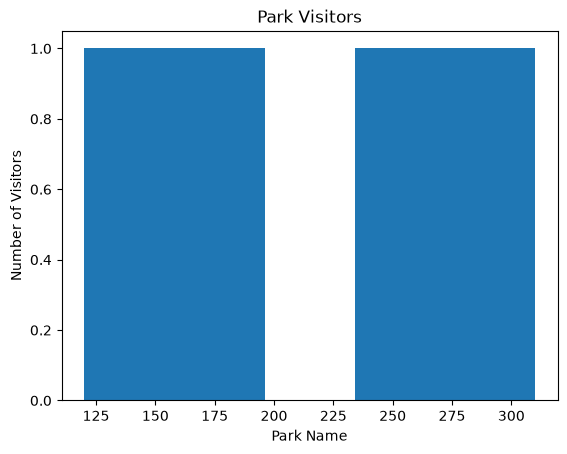

In [14]:
# 27. Write the Matplotlib commands that set a title, x-axis label, and y-axis label on `ax`.
ax = parks["Visitors"].plot(kind="hist", bins=5)
ax.set_title("Park Visitors")
ax.set_xlabel("Park Name")
ax.set_ylabel("Number of Visitors")

28. Explain the difference between equal interval and quantile classification.

Equal interval divides the range of values into equal sized intervals. Quantile divides the data so that each class contains about the same number of observations. 

In [16]:
# 29. Suppose `values = [5, 12, 3, 20]`. Write a short Python loop that prints only values greater than 10. Then write the pandas-style Boolean condition you would use if the same values were in a Series called `s`.
values = [5, 12, 3, 20]

for value in values:
    if value > 10:
        print(value)

s = pd.Series(values)
s[s > 10]


12
20


1    12
3    20
dtype: int64